In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\oorko\OneDrive\Documents\projects\Sales_Forecasting\data\sales_forecast.db"

conn = duckdb.connect(db_path)

# Check all models were created
print("=== TABLES AND VIEWS IN DATABASE ===")
print(conn.execute("SHOW TABLES").fetchdf())

=== TABLES AND VIEWS IN DATABASE ===
                   name
0   mart_sales_features
1          raw_holidays
2               raw_oil
3            raw_stores
4              raw_test
5             raw_train
6      raw_transactions
7          stg_holidays
8               stg_oil
9            stg_stores
10            stg_train
11     stg_transactions


In [2]:
# Check the final mart table
mart = conn.execute("SELECT * FROM mart_sales_features LIMIT 5").fetchdf()
print("=== MART TABLE SAMPLE ===")
print(mart)
print(f"\nColumns: {list(mart.columns)}")
print(f"\nShape: {conn.execute('SELECT COUNT(*) FROM mart_sales_features').fetchone()[0]:,} rows")

=== MART TABLE SAMPLE ===
        date  store_nbr      family  sales  onpromotion  year  month  day  \
0 2013-01-01          1  AUTOMOTIVE    0.0            0  2013      1    1   
1 2013-01-01          1   BABY CARE    0.0            0  2013      1    1   
2 2013-01-01          1      BEAUTY    0.0            0  2013      1    1   
3 2013-01-01          1   BEVERAGES    0.0            0  2013      1    1   
4 2013-01-01          1       BOOKS    0.0            0  2013      1    1   

   day_of_week  week_of_year  ...  cluster  oil_price is_national_holiday  \
0            2             1  ...       13      93.14                   1   
1            2             1  ...       13      93.14                   1   
2            2             1  ...       13      93.14                   1   
3            2             1  ...       13      93.14                   1   
4            2             1  ...       13      93.14                   1   

         holiday_name transactions  sales_lag_7 

In [3]:
# Verify oil forward fill worked
print("=== OIL PRICE NULL CHECK AFTER FORWARD FILL ===")
print(conn.execute("""
    SELECT 
        COUNT(*) as total_rows,
        SUM(CASE WHEN oil_price IS NULL THEN 1 ELSE 0 END) as null_count
    FROM mart_sales_features
""").fetchdf())

=== OIL PRICE NULL CHECK AFTER FORWARD FILL ===
   total_rows  null_count
0     3000888         0.0


In [4]:
# Verify lag features look correct
print("=== LAG FEATURE SAMPLE ===")
print(conn.execute("""
    SELECT date, store_nbr, family, sales, sales_lag_7, sales_lag_14, sales_rolling_7day_avg
    FROM mart_sales_features
    WHERE store_nbr = 1 AND family = 'GROCERY I'
    ORDER BY date
    LIMIT 20
""").fetchdf())

=== LAG FEATURE SAMPLE ===
         date  store_nbr     family   sales  sales_lag_7  sales_lag_14  \
0  2013-01-01          1  GROCERY I     0.0          NaN           NaN   
1  2013-01-02          1  GROCERY I  2652.0          NaN           NaN   
2  2013-01-03          1  GROCERY I  2121.0          NaN           NaN   
3  2013-01-04          1  GROCERY I  2056.0          NaN           NaN   
4  2013-01-05          1  GROCERY I  2216.0          NaN           NaN   
5  2013-01-06          1  GROCERY I   723.0          NaN           NaN   
6  2013-01-07          1  GROCERY I  2262.0          NaN           NaN   
7  2013-01-08          1  GROCERY I  1782.0          0.0           NaN   
8  2013-01-09          1  GROCERY I  2429.0       2652.0           NaN   
9  2013-01-10          1  GROCERY I  1544.0       2121.0           NaN   
10 2013-01-11          1  GROCERY I  1750.0       2056.0           NaN   
11 2013-01-12          1  GROCERY I  1796.0       2216.0           NaN   
12 2013-01-

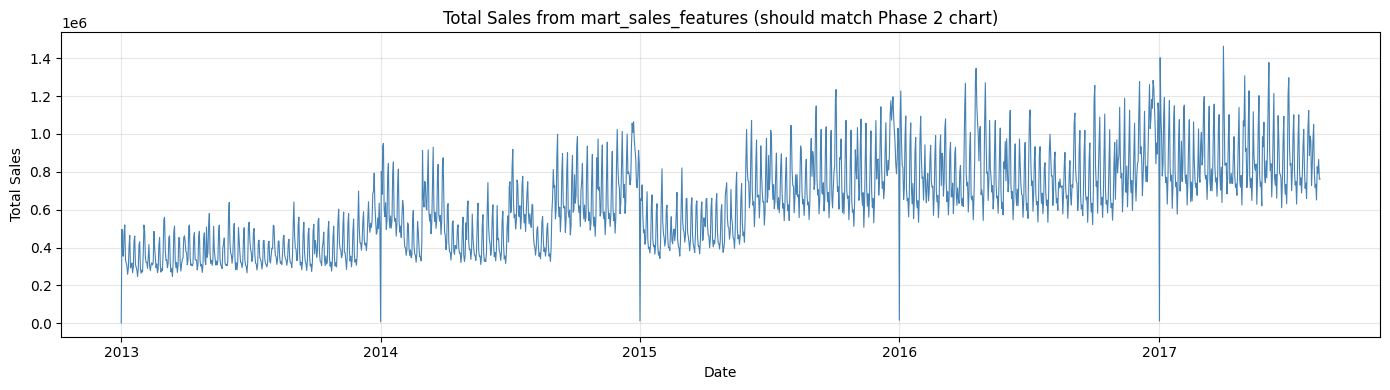

In [5]:
# Quick visual check on mart data
daily = conn.execute("""
    SELECT date, SUM(sales) as total_sales
    FROM mart_sales_features
    GROUP BY date
    ORDER BY date
""").fetchdf()

plt.figure(figsize=(14, 4))
plt.plot(daily['date'], daily['total_sales'], linewidth=0.8, color='steelblue')
plt.title('Total Sales from mart_sales_features (should match Phase 2 chart)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

conn.close()